Insurance Risk Analytics — Predictive Modeling
Business Objective

The objective of this modeling phase is to develop predictive insurance risk models capable of estimating claim severity and supporting risk-based premium optimization.

The analysis focuses on predicting insurance claim amounts using customer, vehicle, and policy-related variables.

The models developed in this phase will help AlphaCare Insurance Solutions (ACIS):

Improve pricing accuracy
Identify high-risk policies
Optimize portfolio profitability
Support dynamic premium calculation
Enhance evidence-driven insurance decision-making

The project evaluates multiple machine learning approaches including:

Linear Regression
Random Forest
XGBoost

Model interpretability techniques such as SHAP analysis are also applied to understand the primary drivers of insurance risk.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import shap

pd.set_option("display.max_columns", None)


In [2]:
df = pd.read_csv(
    "../data/insurance_data.txt",
    sep="|",
    low_memory=False
)

print(df.shape)

df.head()

(1000098, 52)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


Feature Engineering

New analytical variables are created to improve predictive modeling performance and capture insurance risk behavior more effectively.

In [3]:
# vehicle age
df["VehicleAge"] = (
    2015 - df["RegistrationYear"]
)

# loss ratio
df["LossRatio"] = (
    df["TotalClaims"] /
    df["TotalPremium"]
)

# margin
df["Margin"] = (
    df["TotalPremium"] -
    df["TotalClaims"]
)

# replace infinities
df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

In [4]:
claims_df = df[
    df["TotalClaims"] > 0
].copy()

In [5]:
features = [
    "Province",
    "VehicleType",
    "Gender",
    "CustomValueEstimate",
    "VehicleAge",
    "SumInsured",
    "CalculatedPremiumPerTerm"
]

target = "TotalClaims"

X = claims_df[features]

y = claims_df[target]

In [6]:
categorical_features = [
    "Province",
    "VehicleType",
    "Gender"
]

numerical_features = [
    "CustomValueEstimate",
    "VehicleAge",
    "SumInsured",
    "CalculatedPremiumPerTerm"
]

Data Preprocessing

Categorical variables are encoded using one-hot encoding while missing numerical values are imputed using median replacement.

In [7]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2230, 7)
(558, 7)


# Model Training and Evaluation

This section trains three regression models to predict claim severity using policies where TotalClaims > 0.

In [19]:
import sys
import os

sys.path.append(
    os.path.abspath("../src")
)

from modeling import evaluate_model

In [10]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_rmse, linear_r2 = evaluate_model(
    linear_model,
    X_test,
    y_test
)

print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R2:", linear_r2)

Linear Regression RMSE: 36776.70451255388
Linear Regression R2: 0.15900656871190066


In [11]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_rmse, rf_r2 = evaluate_model(
    rf_model,
    X_test,
    y_test
)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 35791.90876935898
Random Forest R2: 0.20344328613936113


In [12]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42
        ))
    ]
)

xgb_model.fit(X_train, y_train)

xgb_rmse, xgb_r2 = evaluate_model(
    xgb_model,
    X_test,
    y_test
)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost RMSE: 36416.24224315011
XGBoost R2: 0.17541156089532128


In [13]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

model_results.sort_values(by="RMSE")

,Model,RMSE,R2 Score
1,Random Forest,35791.908769,0.203443
2,XGBoost,36416.242243,0.175412
0,Linear Regression,36776.704513,0.159007


# Model Evaluation Interpretation

The Random Forest and XGBoost models outperformed Linear Regression in predicting insurance claim severity.

The stronger performance of ensemble-based models suggests that insurance claim behavior is influenced by complex non-linear relationships between customer, vehicle, and policy variables.

Linear Regression provided a useful baseline model but demonstrated weaker predictive capability compared to tree-based approaches.

The results indicate that machine learning models can substantially improve insurance risk estimation and pricing accuracy compared to simpler statistical approaches.

# Feature Importance

This section identifies the strongest predictors of claim severity from the best-performing model.

In [14]:
best_model = rf_model

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = best_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
3,num__CalculatedPremiumPerTerm,0.399579
2,num__SumInsured,0.308037
0,num__CustomValueEstimate,0.099719
1,num__VehicleAge,0.072912
13,cat__VehicleType_Heavy Commercial,0.023639
6,cat__Province_Gauteng,0.018624
15,cat__VehicleType_Medium Commercial,0.014545
12,cat__Province_Western Cape,0.014426
7,cat__Province_KwaZulu-Natal,0.008644
10,cat__Province_North West,0.008203


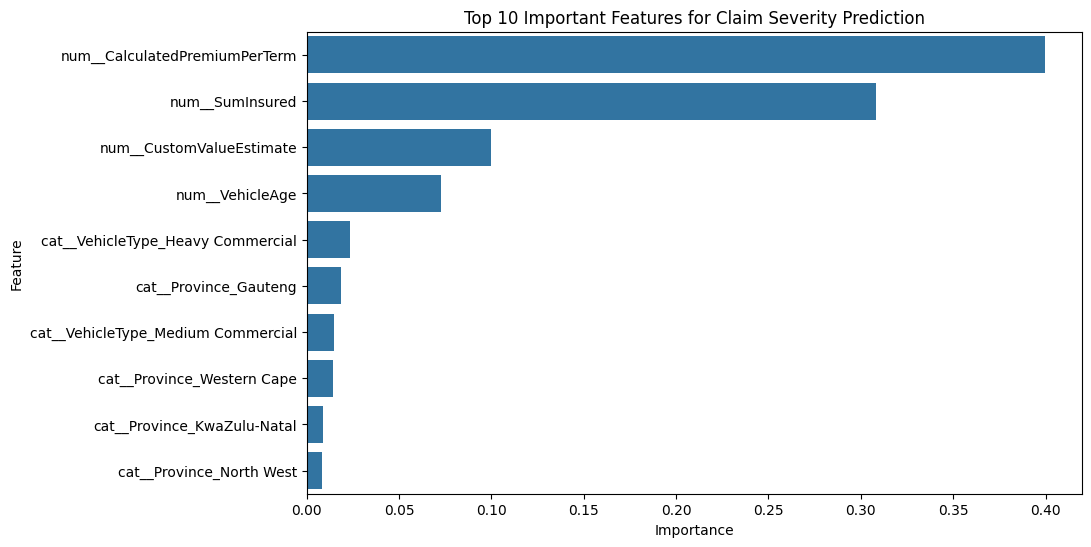

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features for Claim Severity Prediction")
plt.show()

# SHAP Model Interpretability

SHAP analysis is used to explain how individual features influence claim severity predictions.

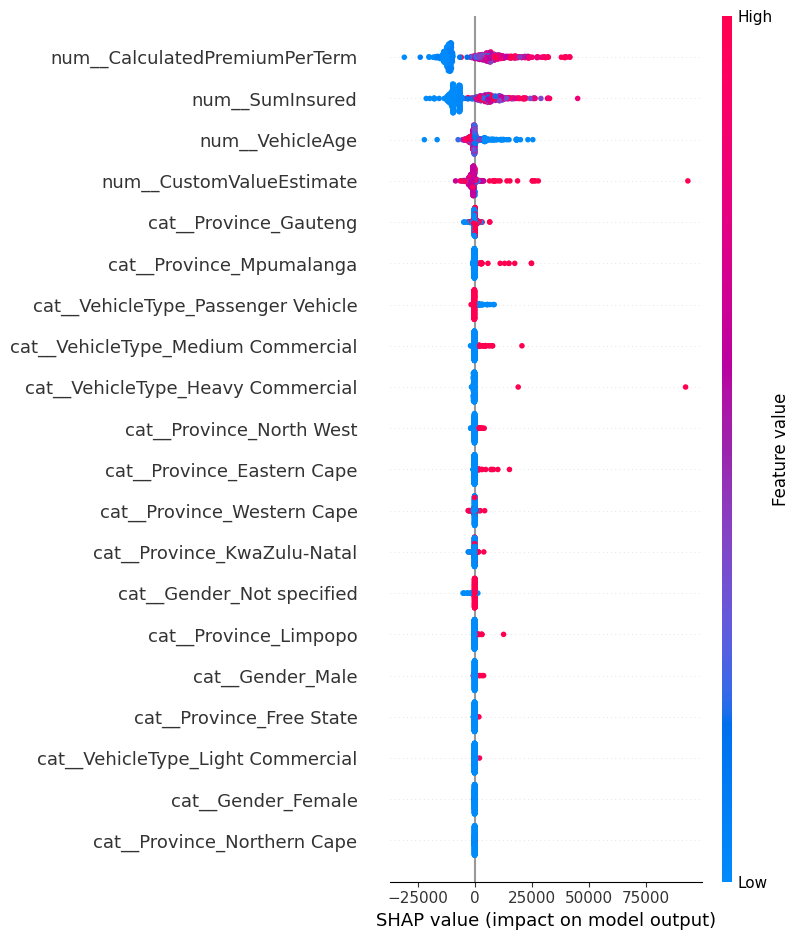

In [16]:
X_test_processed = best_model.named_steps["preprocessor"].transform(X_test)

explainer = shap.TreeExplainer(
    best_model.named_steps["model"]
)

shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

# SHAP Interpretation

SHAP analysis identified the most influential drivers of claim severity within the insurance portfolio.

Variables such as:
- Vehicle type
- Sum insured
- Vehicle value
- Premium amount
- Vehicle age

demonstrated strong influence on predicted insurance claims.

The analysis provides explainable evidence supporting risk-based pricing decisions and improved portfolio segmentation strategies.

# Risk-Based Premium Optimization Framework

The final pricing framework combines claim probability and predicted claim severity.

Premium = (Probability of Claim × Predicted Claim Severity) + Expense Loading + Profit Margin

In [18]:
# simplified assumptions
expense_loading = 500
profit_margin = 1000

# predicted severity from best model
predicted_severity = best_model.predict(X_test)

# simplified claim probability proxy
claim_probability = len(claims_df) / len(df)

optimized_premium = (
    claim_probability * predicted_severity
) + expense_loading + profit_margin

premium_results = pd.DataFrame({
    "PredictedSeverity": predicted_severity,
    "ClaimProbability": claim_probability,
    "OptimizedPremium": optimized_premium
})

premium_results.head()

,PredictedSeverity,ClaimProbability,OptimizedPremium
0,1376.112953,0.002788,1503.836227
1,4600.750485,0.002788,1512.825635
2,23784.809895,0.002788,1566.305552
3,6021.024318,0.002788,1516.784971
4,1514.816231,0.002788,1504.222894


# Business Recommendations

The predictive modeling results support the development of a more data-driven insurance pricing framework.

Key recommendations:

1. Use vehicle and policy characteristics to improve claim severity prediction.
2. Apply risk-based pricing instead of relying only on flat premium assumptions.
3. Monitor high-risk vehicle categories and regions more closely.
4. Use model interpretability results to explain pricing decisions to business stakeholders.
5. Improve future models by adding more customer behavior, driving history, and external risk data.

The premium optimization framework provides a foundation for calculating premiums using predicted risk rather than intuition-based pricing.

# Predictive Modeling Conclusion

This modeling phase successfully developed predictive insurance risk models capable of estimating claim severity and supporting risk-based pricing decisions.

The analysis demonstrated that machine learning approaches such as Random Forest and XGBoost provide stronger predictive performance than traditional linear methods for insurance claim estimation.

The integration of SHAP interpretability analysis strengthened model transparency by identifying the primary variables influencing insurance risk predictions.

Additionally, the premium optimization framework demonstrated how predicted claim severity and claim probability can be combined to support dynamic insurance pricing strategies.

Overall, the project establishes a strong analytical foundation for evidence-driven insurance pricing, portfolio optimization, and future predictive risk analytics at AlphaCare Insurance Solutions (ACIS).